Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


c:\Users\dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\dell\OneDrive\DATA SCIENCE\Projects for data science\Customer Churn - ANN project\Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.duplicated().sum()

0

In [7]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

Drop useless columns

In [10]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [11]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Encoding (1 & 0 only)

In [12]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype=int)

In [13]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


Feature & Target Split

In [14]:
x = df.drop(columns=['Exited'])
y = df['Exited']

Train - Test Split

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [16]:
x

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [17]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [18]:
x_train.shape

(8000, 11)

In [19]:
x_test.shape

(2000, 11)

Feature Scaling

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [21]:
x_train_scaled

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

Neural Network Model

In [23]:
model = Sequential()

model.add(Dense(11,activation='sigmoid',input_dim=11))
model.add(Dense(11,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

In [24]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

Model Training

In [26]:

history = model.fit(x_train_scaled,y_train,epochs=50,batch_size=32,validation_split=0.2)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7958 - loss: 0.5133 - val_accuracy: 0.7969 - val_loss: 0.4950
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7958 - loss: 0.4896 - val_accuracy: 0.7969 - val_loss: 0.4795
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7958 - loss: 0.4707 - val_accuracy: 0.7969 - val_loss: 0.4607
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7958 - loss: 0.4515 - val_accuracy: 0.7969 - val_loss: 0.4451
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7986 - loss: 0.4369 - val_accuracy: 0.8000 - val_loss: 0.4356
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8073 - loss: 0.4287 - val_accuracy: 0.8156 - val_loss: 0.4310
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8138 - loss: 0.4241 - val_accuracy: 0.8169 - val_loss: 0.4291
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8161 - loss: 0.4223 - val_accuracy: 0.

In [27]:
model.layers[0].get_weights()

[array([[ 0.11807282, -0.03133804,  0.43376312, -0.23649523,  0.1048917 ,
         -0.27837446, -0.07740284,  0.1997345 , -0.10595032, -0.02404246,
         -0.0801405 ],
        [ 0.11737197, -0.78441256,  0.5048149 ,  0.17924187, -2.0741458 ,
          1.9744165 ,  0.8200723 , -1.6850951 ,  0.22521429,  1.9220995 ,
          0.35973343],
        [ 0.07532617, -0.07694793,  0.41082016, -0.36586556,  0.32000265,
          0.24885976,  0.12282701,  0.34549254, -0.22752967, -0.20200677,
          0.24087039],
        [-0.13368046, -0.28566426, -1.0701385 , -0.03621605,  0.06043155,
          0.15881722,  0.73570156, -0.07492165, -0.0702881 , -0.05538917,
         -0.3610354 ],
        [-0.5719157 ,  0.18703741, -0.5842516 , -0.8279492 , -0.64133096,
          0.51909435,  3.3599722 , -0.5398425 , -0.8589023 ,  0.51126826,
         -0.47864065],
        [ 0.2324378 ,  0.27888438,  0.28000352,  0.02222365,  0.20174015,
          0.26266265, -0.04716833,  0.14014095, -0.04086156, -0.1215790

In [28]:
model.layers[1].get_weights()

[array([[-2.74023533e-01, -3.99938673e-01, -1.61433652e-01,
         -1.77885339e-01, -2.04574004e-01,  6.90373898e-01,
          1.76733702e-01,  8.11023489e-02,  1.18967995e-01,
          6.29355371e-01,  1.28448680e-01],
        [ 7.13670075e-01, -2.92284906e-01, -4.53713536e-01,
          1.97886795e-01,  1.77904218e-01, -1.43648654e-01,
          2.18774509e-02,  3.91866177e-01,  3.31610709e-01,
         -1.99059695e-01, -4.20984216e-02],
        [-4.09847826e-01, -9.35525358e-01,  7.41504729e-01,
          5.77960432e-01, -2.20962986e-02,  6.72164559e-01,
         -3.67152721e-01, -2.79290885e-01,  4.39085439e-02,
          3.20630521e-01,  5.73660314e-01],
        [-7.28907704e-01, -9.66534078e-01,  7.21515238e-01,
          6.60062134e-01,  5.39820313e-01,  1.08806618e-01,
         -9.02308345e-01, -1.01952374e+00,  7.50086546e-01,
          7.60889292e-01,  7.77387977e-01],
        [ 9.03988779e-02, -1.24818969e+00,  1.05583870e+00,
          9.48637009e-01,  9.21243012e-01,  

In [29]:
model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


array([[0.23211683],
       [0.33364108],
       [0.19201797],
       ...,
       [0.09269629],
       [0.1294175 ],
       [0.25831178]], dtype=float32)

Model Evaluation

In [30]:
y_log = model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [31]:
y_log

array([[0.23211683],
       [0.33364108],
       [0.19201797],
       ...,
       [0.09269629],
       [0.1294175 ],
       [0.25831178]], dtype=float32)

In [32]:
y_pred = np.where(y_log>0.5,1,0)

In [33]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.859

In [34]:
import matplotlib.pyplot as plt

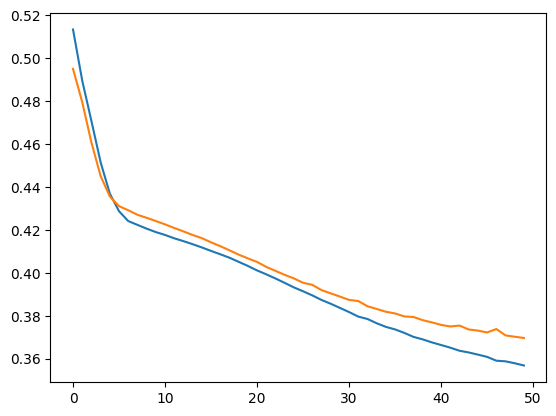

In [35]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

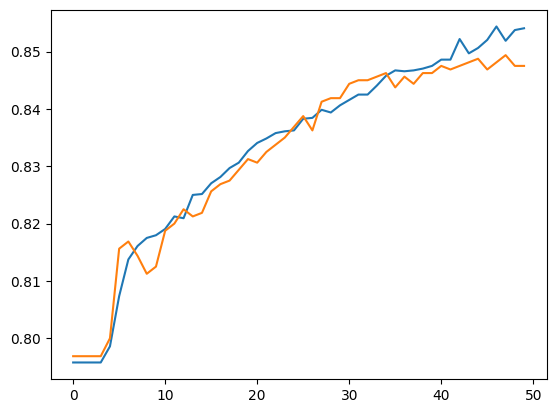

In [36]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [37]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


# Predicting New Customer

In [38]:
new_customer = np.array([[600, 40, 3, 60000, 2, 1, 1, 50000, 1, 0,1]])

new_customer = scaler.transform(new_customer)

prediction = model.predict(new_customer)

print("Churn" if prediction > 0.5 else "Not Churn")


c:\Users\dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Not Churn


In [39]:
model.save_weights("churn.weights.h5")


In [40]:
import joblib
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']